# Chromhandler priors module — demo & verification

This notebook walks through the new `chromhandler.fitting.priors` module:

- **Synthetic kinetic series + controls**: build a 5-sample / 2-control dataset with known artefact and analyte parameters.
- **Run `build_priors`** end-to-end on top of the foundations layer.
- **Verify** that the controls-based extraction recovers the synthesized parameters within tolerance.
- **Demonstrate** the side check, peaks-too-close guard, and `PriorConfig` overrides.
- **Visualize** the priors as overlaid skew-normal densities.

Companion to `foundations_demo.ipynb` (data prep) and `skew_normal_demo.ipynb` (math layer).

## 1. Synthetic kinetic series + controls

We simulate a chromatographic experiment:

- **Analyte** at retention time 3.00 min, decaying across 5 samples (kinetic series: 100 → 60 → 35 → 15 → 5).
- **Artefact** at retention time 3.05 min, constant area = 3 (a small persistent contaminant).
- **2 control traces** with the analyte absent (only the artefact + noise).
- All traces share the same baseline (`10 + 0.5·t`) and noise level.

Mirrors a real enzyme-kinetics experiment where substrate concentration drops over time and a derivatisation artefact persists at fixed concentration.

In [1]:
from __future__ import annotations

import numpy as np
from scipy.stats import skewnorm

from chromhandler.fitting.skew_normal import cp_to_dp

rng = np.random.default_rng(42)

# Peak parameters (centred parameterisation: mu, sigma, gamma1)
MU_ANALYTE = 3.00
MU_ARTEFACT = 3.05
SIGMA_ANALYTE = 0.025
SIGMA_ARTEFACT = 0.025
GAMMA1_ANALYTE = 0.2
GAMMA1_ARTEFACT = 0.0

# Kinetic series: analyte area decays; artefact constant
ANALYTE_AREAS = [100.0, 60.0, 35.0, 15.0, 5.0]
ARTEFACT_AREA = 3.0
NOISE_STD = 0.5

# Time axis
t_axis = np.arange(2.5, 3.6, 0.001)

# CP -> DP for scipy.stats.skewnorm
xi_a, om_a, al_a = (float(x) for x in cp_to_dp(MU_ANALYTE, SIGMA_ANALYTE, GAMMA1_ANALYTE))
xi_x, om_x, al_x = (float(x) for x in cp_to_dp(MU_ARTEFACT, SIGMA_ARTEFACT, GAMMA1_ARTEFACT))

times: list[np.ndarray] = []
signals: list[np.ndarray] = []
is_control: list[bool] = []

for A_an in ANALYTE_AREAS:
    s_an = A_an * skewnorm.pdf(t_axis, al_a, loc=xi_a, scale=om_a)
    s_x = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_x, loc=xi_x, scale=om_x)
    baseline = 10.0 + 0.5 * t_axis
    noise = rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    times.append(t_axis.copy())
    signals.append(s_an + s_x + baseline + noise)
    is_control.append(False)

for _ in range(2):
    s_x = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_x, loc=xi_x, scale=om_x)
    baseline = 10.0 + 0.5 * t_axis
    noise = rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    times.append(t_axis.copy())
    signals.append(s_x + baseline + noise)
    is_control.append(True)

print(f'n_trace = {len(times)} ({sum(is_control)} controls)')
print(f'analyte areas (sample traces): {ANALYTE_AREAS}')
print(f'artefact area (constant):       {ARTEFACT_AREA}')

/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


n_trace = 7 (2 controls)
analyte areas (sample traces): [100.0, 60.0, 35.0, 15.0, 5.0]
artefact area (constant):       3.0


Quick look at the raw data — sample traces show two peaks (analyte big, artefact small shoulder); controls show only the artefact.

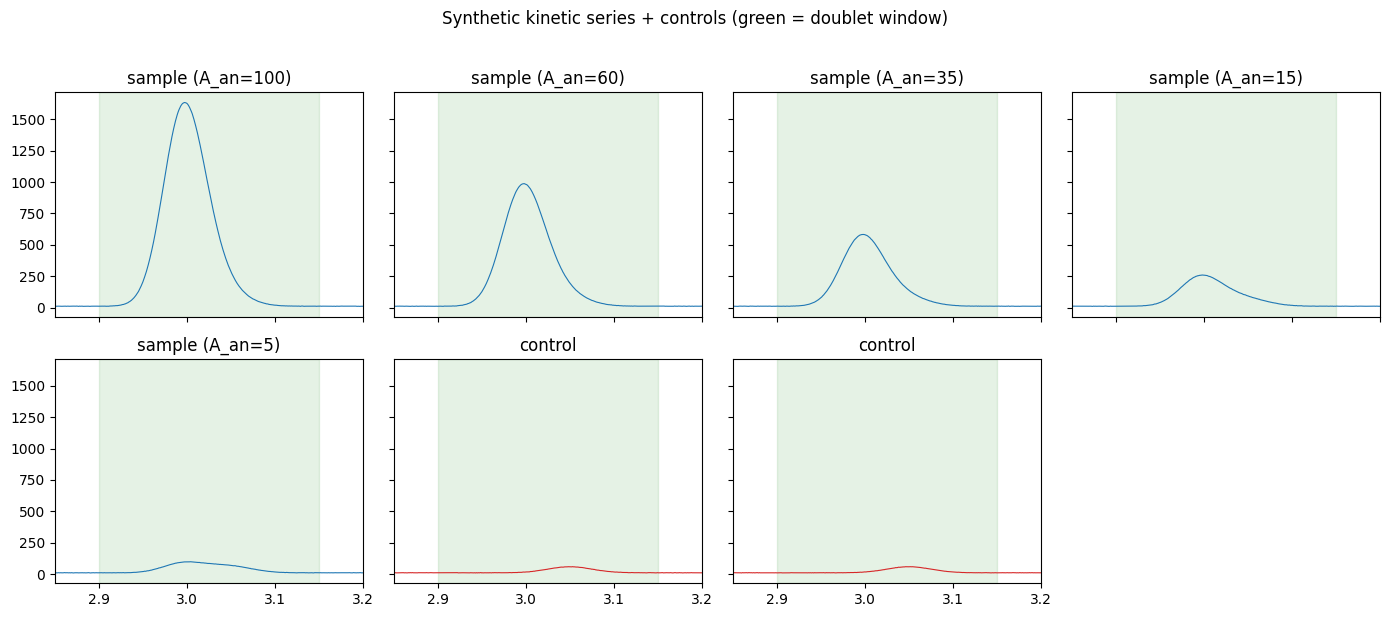

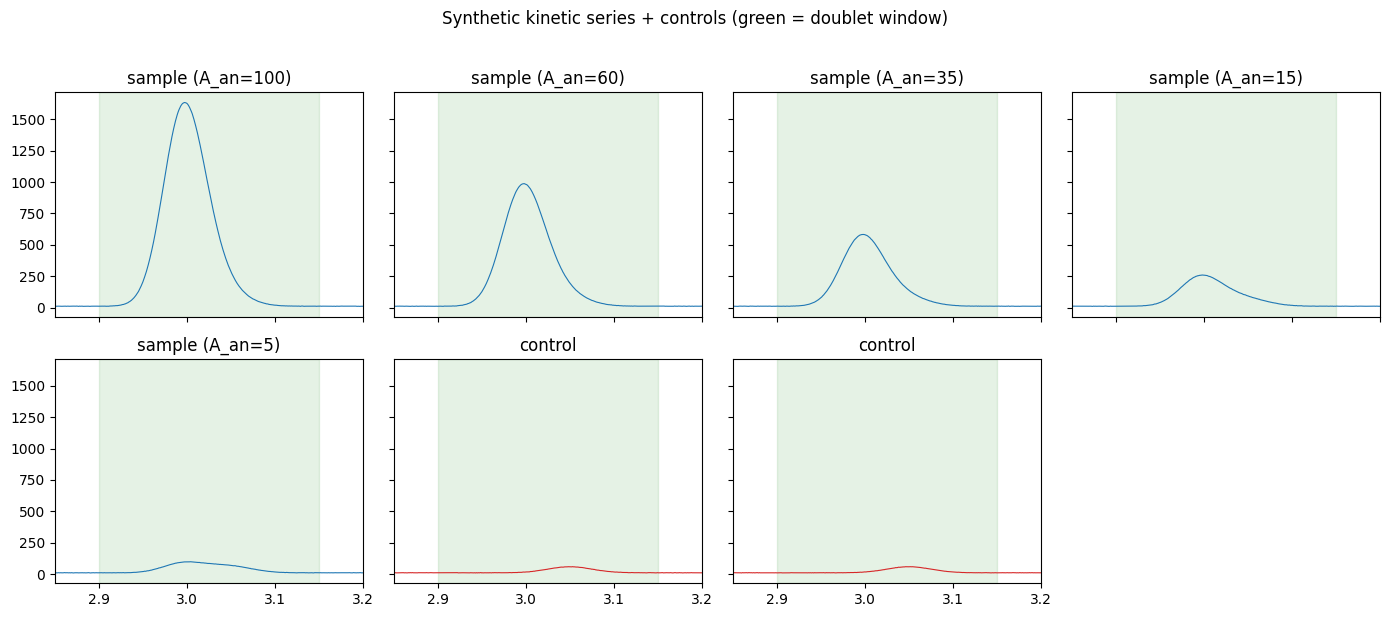

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
ax_flat = axes.flatten()
for i, (t_i, s_i, ic) in enumerate(zip(times, signals, is_control, strict=True)):
    ax = ax_flat[i]
    color = 'C3' if ic else 'C0'
    label = 'control' if ic else f'sample (A_an={ANALYTE_AREAS[i]:.0f})'
    ax.plot(t_i, s_i, color=color, lw=0.8)
    ax.set_title(label)
    ax.axvspan(2.90, 3.15, color='green', alpha=0.1)
    ax.set_xlim(2.85, 3.20)
for ax in ax_flat[len(times):]:
    ax.axis('off')
fig.suptitle('Synthetic kinetic series + controls (green = doublet window)', y=1.02)
fig.tight_layout()
fig

## 2. Build the `PreparedDataset`

Annotate the doublet (analyte + artefact, artefact on the right) and two baseline regions, then run `prepare_dataset`. The `is_control` list flows through the pipeline and becomes a per-trace bool mask on the dataset.

In [3]:
from chromhandler.annotations import BaselineAnnotation, PeakAnnotation
from chromhandler.fitting.prepared_dataset import prepare_dataset

peak_anns = [
    PeakAnnotation(
        molecule_id='X',
        rt_min=2.90,
        rt_max=3.15,
        mode='artefact_doublet',
        artefact_side='right',
    ),
]
base_anns = [
    BaselineAnnotation(rt_min=2.55, rt_max=2.58),
    BaselineAnnotation(rt_min=3.55, rt_max=3.58),
]

dataset = prepare_dataset(
    times, signals, peak_anns, base_anns, is_control=is_control,
)
print(f'n_trace = {dataset.n_trace}')
print(f'is_control = {dataset.is_control}')
print(f'control trace indices = {np.where(dataset.is_control)[0].tolist()}')
print(f'baseline_intercept = {np.round(dataset.baseline_intercept, 2)}')
print(f'baseline_slope     = {np.round(dataset.baseline_slope, 4)}')
print(f'noise per trace    = {np.round(dataset.noise_per_trace, 3)}')

n_trace = 7
is_control = [False False False False False  True  True]
control trace indices = [5, 6]
baseline_intercept = [ 9.56  9.37  9.94  9.51 10.36 10.49 10.08]
baseline_slope     = [0.6561 0.6834 0.4842 0.603  0.4074 0.3262 0.4633]
noise per trace    = [0.502 0.505 0.537 0.448 0.466 0.515 0.446]


## 3. Run `build_priors`

One call. The orchestrator:

1. Aggregates analyte features from non-control traces via FWHM extraction.
2. Extracts artefact features (shape, area, position) directly from control traces.
3. Runs the side check (raises if `artefact_side` is wrong or peaks too close).
4. Computes the Δ separation prior empirically from `μ_artefact − μ_analyte_ref`.
5. Assembles a `SkewNormalPriors(n_components=2)` for the doublet.

Every threshold and fallback lives in `PriorConfig`. The defaults are tuned for typical chromatographic data.

In [4]:
from chromhandler.fitting.priors import PriorConfig, build_priors, summarise_priors

config = PriorConfig()
priors = build_priors(dataset, config=config)
print(f'n_priors = {len(priors)}  (one per peak annotation)')
print(f'n_components[0] = {priors[0].n_components}')
print()
print(summarise_priors(priors, config=config))

n_priors = 1  (one per peak annotation)
n_components[0] = 2

peak site                   distribution            loc      scale        low       high
----------------------------------------------------------------------------------------
   0 mu_anchor_left         TruncatedNormal       2.999   0.002332        2.9       3.15
   0 log_sigma_left         TruncatedNormal      -3.566     0.1755     -5.685     -3.178
   0 gamma1_left            TruncatedNormal      0.3863     0.2265    -0.9853     0.9853
   0 log_A_left (mean)      Normal               0.9847     0.0378          -          -
   0 Delta                  TruncatedNormal        0.05   0.001061      0.003      0.125
   0 log_sigma_right        TruncatedNormal      -3.688     0.1241     -5.685     -3.178
   0 gamma1_right           TruncatedNormal     0.05871     0.1602    -0.9853     0.9853
   0 log_A_right (mean)     Normal                1.102        0.2          -          -


## 4. Sanity-check the recovery

We know the ground truth (we synthesized it). Compare against the extracted priors.

In [5]:
p = priors[0]
delta_true = MU_ARTEFACT - MU_ANALYTE

print('=== Analyte (left component) ===')
print(f'  mu       true {MU_ANALYTE:.3f}    loc {p.mu_left_loc:.3f}    err {abs(p.mu_left_loc - MU_ANALYTE):.4f} min')
print(f'  sigma    true {SIGMA_ANALYTE:.4f}   loc {np.exp(p.log_sigma_left_loc):.4f}   err {abs(np.exp(p.log_sigma_left_loc) - SIGMA_ANALYTE) / SIGMA_ANALYTE * 100:.1f}%')
print(f'  gamma1   true {GAMMA1_ANALYTE:.2f}     loc {p.gamma1_left_loc:.2f}     err {abs(p.gamma1_left_loc - GAMMA1_ANALYTE):.2f}')
print()
print('=== Artefact (right component, from controls) ===')
print(f'  sigma    true {SIGMA_ARTEFACT:.4f}   loc {np.exp(p.log_sigma_right_loc):.4f}   err {abs(np.exp(p.log_sigma_right_loc) - SIGMA_ARTEFACT) / SIGMA_ARTEFACT * 100:.1f}%')
print(f'  gamma1   true {GAMMA1_ARTEFACT:.2f}     loc {p.gamma1_right_loc:.2f}     err {abs(p.gamma1_right_loc - GAMMA1_ARTEFACT):.2f}')
print()
print('=== Δ (separation) ===')
print(f'  loc      true {delta_true:.3f}    loc {p.Delta_loc:.3f}    err {abs(p.Delta_loc - delta_true):.4f} min')
print(f'  scale    {p.Delta_scale:.4f} min   (n_controls=2 → empirical std)')
print(f'  bounds   [{p.Delta_low:.4f}, {p.Delta_high:.4f}] (TruncatedNormal truncation)')
print()
print('=== Per-trace analyte areas (sample traces only) ===')
A_recovered = np.exp(p.log_A_left_loc_per_trace[~dataset.is_control])
for i, (a_t, a_r) in enumerate(zip(ANALYTE_AREAS, A_recovered, strict=True)):
    err_pct = abs(a_r - a_t) / a_t * 100
    print(f'  trace {i}: true {a_t:>6.1f}   recovered {a_r:>6.2f}   err {err_pct:>5.1f}%')
print()
print('=== Artefact area (single value, applied to every trace) ===')
A_x_recovered = np.exp(p.log_A_right_loc_per_trace[0])
print(f'  true {ARTEFACT_AREA:.2f}   recovered {A_x_recovered:.2f}   err {abs(A_x_recovered - ARTEFACT_AREA) / ARTEFACT_AREA * 100:.1f}%')

=== Analyte (left component) ===
  mu       true 3.000    loc 2.999    err 0.0006 min
  sigma    true 0.0250   loc 0.0283   err 13.1%
  gamma1   true 0.20     loc 0.39     err 0.19

=== Artefact (right component, from controls) ===
  sigma    true 0.0250   loc 0.0250   err 0.0%
  gamma1   true 0.00     loc 0.06     err 0.06

=== Δ (separation) ===
  loc      true 0.050    loc 0.050    err 0.0000 min
  scale    0.0011 min   (n_controls=2 → empirical std)
  bounds   [0.0030, 0.1250] (TruncatedNormal truncation)

=== Per-trace analyte areas (sample traces only) ===
  trace 0: true  100.0   recovered  99.97   err   0.0%
  trace 1: true   60.0   recovered  59.99   err   0.0%
  trace 2: true   35.0   recovered  35.02   err   0.1%
  trace 3: true   15.0   recovered  15.03   err   0.2%
  trace 4: true    5.0   recovered   4.95   err   0.9%

=== Artefact area (single value, applied to every trace) ===
  true 3.00   recovered 3.01   err 0.3%


**What you should see — and the one honest caveat:**

- **Analyte μ exact** (sub-`dt` error) — the apex location is robust against the artefact's small contribution.
- **Analyte σ ~13% high, γ₁ shifted +0.19** — this is *real* and worth understanding. The analyte's right-side HWHM (in non-control traces) gets pushed outward by the artefact's left tail, inflating both `σ` (via the sum `HWHM_L + HWHM_R`) and `γ₁` (via the ratio `HWHM_R / HWHM_L`). FWHM extraction on a contaminated peak is biased by construction. This is exactly the kind of bias the downstream MCMC fit is designed to correct: shared shape priors give it a starting point in the right neighborhood, and the likelihood pulls it to the truth using all traces simultaneously. Wide enough prior scales (which `PriorConfig`'s floors ensure) let the posterior travel that distance.
- **Artefact σ, γ₁ recovered exactly** — measured directly from controls where there is *no* analyte contamination. This is the whole point of the controls-based approach.
- **Δ_loc essentially exact** (controls give us μ_artefact directly; the max-A non-control trace gives μ_analyte_ref).
- **Per-trace analyte areas track the kinetic decay to ~1%.** The smallest one (trace 4, A=5) shows the largest relative error because it's closest to the noise + baseline-uncertainty floor.
- **Artefact area is the mean across controls** — the per-trace `log_A_right_loc` is the same value for every trace (artefact chemistry is constant).

## 5. Side check demo

The orchestrator refuses to commit when:

- The user-annotated `artefact_side` doesn't match the observed apex positions.
- The artefact and analyte apexes are within `side_check_epsilon_dt_multiplier · dt` of each other (peaks too close to resolve at sampling resolution).

In [6]:
# Misannotate: artefact is at 3.05 (right of analyte at 3.00), but user says 'left'.
bad_anns = [
    PeakAnnotation(
        molecule_id='X', rt_min=2.90, rt_max=3.15,
        mode='artefact_doublet', artefact_side='left',  # WRONG
    ),
]
bad_dataset = prepare_dataset(
    times, signals, bad_anns, base_anns, is_control=is_control,
)
try:
    build_priors(bad_dataset)
except ValueError as e:
    msg = str(e)
    print('ValueError raised (truncated):')
    print(msg[:300] + ('...' if len(msg) > 300 else ''))

ValueError raised (truncated):
Peak X: artefact_side='left' but controls indicate artefact is on the right side (mu_artefact=3.0480 from controls ['trace_5', 'trace_6']; mu_analyte_ref=2.9980 from trace 'trace_0'; delta=+0.0500). Fix artefact_side, or check whether ['trace_5', 'trace_6'] are really controls.


In [7]:
# Synthesize peaks just 2.5·dt apart (below the default 3·dt epsilon).
MU_ARTEFACT_CLOSE = MU_ANALYTE + 0.0025  # 2.5 * dt = 2.5 ms shift
xi_xc, om_xc, al_xc = (float(x) for x in cp_to_dp(MU_ARTEFACT_CLOSE, SIGMA_ARTEFACT, GAMMA1_ARTEFACT))
close_times: list[np.ndarray] = []
close_signals: list[np.ndarray] = []
close_ic: list[bool] = []
for A_an in ANALYTE_AREAS:
    s = A_an * skewnorm.pdf(t_axis, al_a, loc=xi_a, scale=om_a)
    s += ARTEFACT_AREA * skewnorm.pdf(t_axis, al_xc, loc=xi_xc, scale=om_xc)
    s += 10.0 + 0.5 * t_axis + rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    close_times.append(t_axis.copy()); close_signals.append(s); close_ic.append(False)
for _ in range(2):
    s = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_xc, loc=xi_xc, scale=om_xc)
    s += 10.0 + 0.5 * t_axis + rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    close_times.append(t_axis.copy()); close_signals.append(s); close_ic.append(True)

close_ds = prepare_dataset(close_times, close_signals, peak_anns, base_anns, is_control=close_ic)
try:
    build_priors(close_ds)
except ValueError as e:
    msg = str(e)
    print('ValueError raised (truncated):')
    print(msg[:350] + ('...' if len(msg) > 350 else ''))

## 6. `PriorConfig` overrides

Every knob lives in one dataclass. Override what you need; the rest stays at defaults.

In [8]:
# Loosen the side check — the 'too close' case above now passes.
loose_cfg = PriorConfig(side_check_epsilon_dt_multiplier=1.5)
priors_loose = build_priors(close_ds, config=loose_cfg)
print(f'side_check_epsilon_dt_multiplier=1.5: Δ_loc = {priors_loose[0].Delta_loc:.4f} min '
      f'(expected ~{0.0025:.4f})')

# Tighter Δ bounds.
tighter_cfg = PriorConfig(delta_low_dt_multiplier=5.0, delta_high_window_fraction=4.0)
priors_tighter = build_priors(dataset, config=tighter_cfg)
p_t = priors_tighter[0]
print(f'\nWith tighter Δ bounds:')
print(f'  Δ_low  = {p_t.Delta_low:.4f}  (was {priors[0].Delta_low:.4f})')
print(f'  Δ_high = {p_t.Delta_high:.4f}  (was {priors[0].Delta_high:.4f})')
print(f'  Δ_loc  = {p_t.Delta_loc:.4f}   (unchanged — empirical from controls)')

# Wider gamma1 prior (e.g., for unusual peak shapes).
wide_g1 = PriorConfig(gamma1_scale_n1=0.40)
priors_wide_g1 = build_priors(dataset, config=wide_g1)
print(f'\ngamma1_scale_n1=0.40: gamma1_left_scale = {priors_wide_g1[0].gamma1_left_scale:.3f}')

side_check_epsilon_dt_multiplier=1.5: Δ_loc = 0.0060 min (expected ~0.0025)

With tighter Δ bounds:
  Δ_low  = 0.0050  (was 0.0030)
  Δ_high = 0.0625  (was 0.1250)
  Δ_loc  = 0.0500   (unchanged — empirical from controls)

gamma1_scale_n1=0.40: gamma1_left_scale = 0.227


## 7. Visualize the prior loc as skew-normal densities

Overlay the recovered prior **center estimates** (loc values, in CP) as skew-normal curves on top of the baseline-subtracted data. The recovered shapes should track the synthesized shapes.

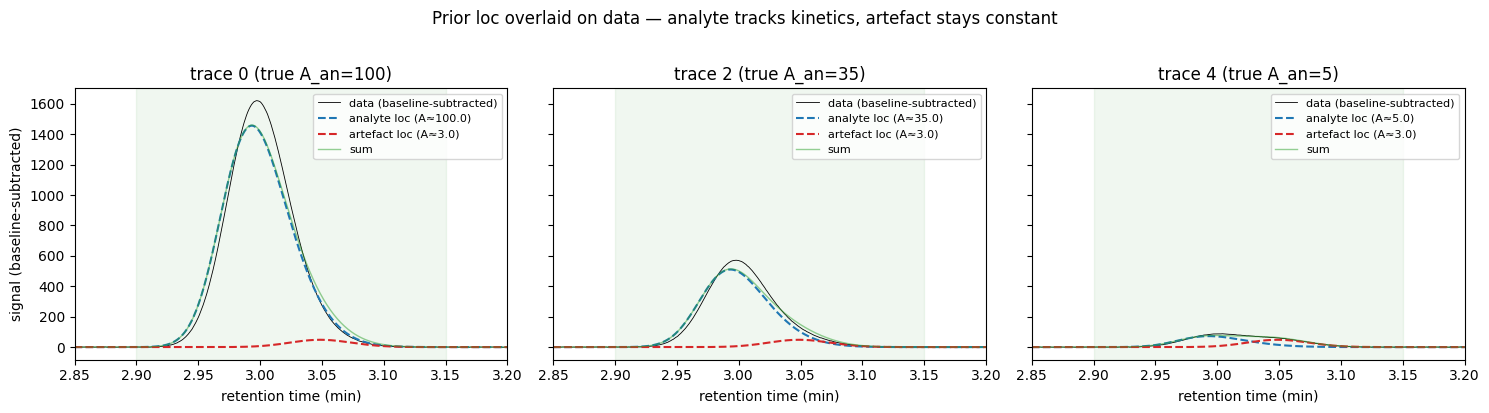

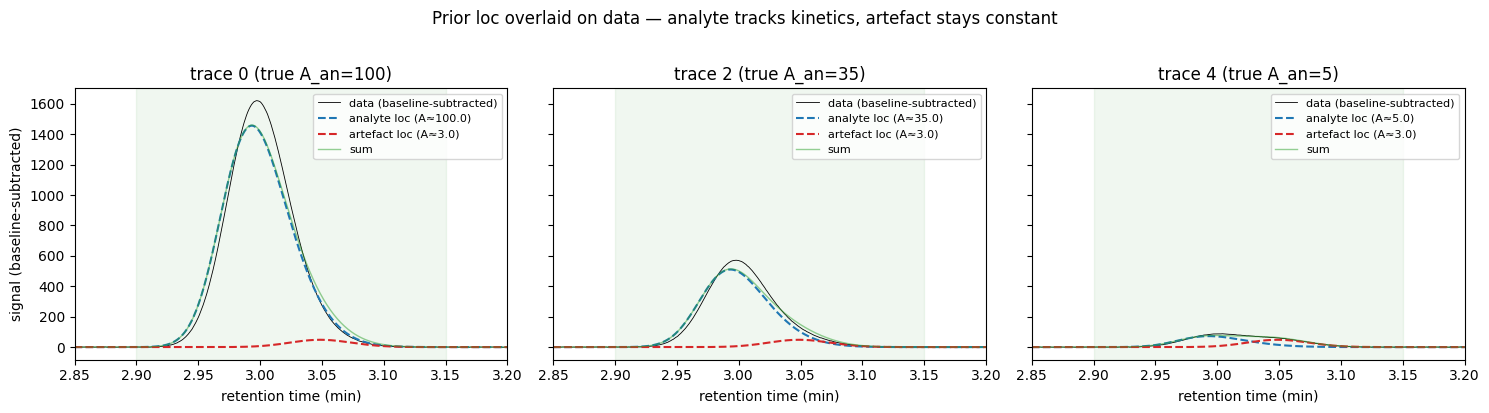

In [9]:
from chromhandler.fitting.skew_normal import density_cp

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

show_indices = [0, 2, 4]  # high, mid, low analyte sample traces
t_dense = np.linspace(2.85, 3.20, 500)

for ax, idx in zip(axes, show_indices, strict=True):
    bs_signal = signals[idx] - (dataset.baseline_intercept[idx] + dataset.baseline_slope[idx] * times[idx])
    ax.plot(times[idx], bs_signal, 'k-', lw=0.6, label='data (baseline-subtracted)')

    A_an_prior = float(np.exp(p.log_A_left_loc_per_trace[idx]))
    A_x_prior = float(np.exp(p.log_A_right_loc_per_trace[idx]))
    mu_art = p.mu_left_loc + p.Delta_loc

    sn_an = A_an_prior * np.asarray(density_cp(
        t_dense, p.mu_left_loc, float(np.exp(p.log_sigma_left_loc)), p.gamma1_left_loc,
    ))
    sn_art = A_x_prior * np.asarray(density_cp(
        t_dense, mu_art, float(np.exp(p.log_sigma_right_loc)), p.gamma1_right_loc,
    ))
    ax.plot(t_dense, sn_an, 'C0--', lw=1.5, label=f'analyte loc (A≈{A_an_prior:.1f})')
    ax.plot(t_dense, sn_art, 'C3--', lw=1.5, label=f'artefact loc (A≈{A_x_prior:.1f})')
    ax.plot(t_dense, sn_an + sn_art, 'C2-', lw=1.0, alpha=0.5, label='sum')
    ax.axvspan(peak_anns[0].rt_min, peak_anns[0].rt_max, color='green', alpha=0.06)
    ax.set_xlim(2.85, 3.20)
    ax.set_xlabel('retention time (min)')
    ax.set_title(f'trace {idx} (true A_an={ANALYTE_AREAS[idx]:.0f})')
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('signal (baseline-subtracted)')
fig.suptitle('Prior loc overlaid on data — analyte tracks kinetics, artefact stays constant', y=1.02)
fig.tight_layout()
fig

## 9. Real data — ASM kinetic series + conditions CSV

The synthetic demo above exercises every code path of `build_priors`. Now we point the same pipeline at the real ASM kinetic-series fixture (`tests/fixtures/asm_kinetic_series/`) and demonstrate two things:

- The **registered-molecule filter** in `Handler.load_initial_conditions` — when we register only `SIH`, `Hyp`, `Ino` as molecules, the derivatization reagent `DTNB` (present at 800 µM in every row of `conditions.csv`) is silently skipped, and auto-detection correctly identifies the blank samples as controls.
- The full pipeline running end-to-end on six real samples (CV1, CV2, CV3, CV4, CV5, CV10) with two of them (CV4, CV5) auto-detected as controls, fitting **single-mode** priors for each of the three analytes.

The fixture is a dir-of-dirs layout: each sample is a sub-directory of ASM JSON timepoint files. CV4 is a "full blank" (no analytes, only DTNB), CV5 is "enzyme without substrate", CV1–CV3 are "no-enzyme" no-conversion samples, and CV10 is the 7-timepoint kinetic series of the SIH→Hyp+Ino conversion.

In [10]:
from pathlib import Path

from chromhandler.handler import Handler

ASM_DIR = Path.cwd().parent / "tests" / "fixtures" / "asm_kinetic_series"
CONDITIONS_CSV = ASM_DIR / "conditions.csv"

handler = Handler.read_asm(path=ASM_DIR, mode="timecourse")

# Register only the analytes we care about. SAH, DTNB, SIHH are also in the
# conditions CSV but we deliberately do NOT register them — the filter in
# load_initial_conditions will skip them.
for mol_id in ("SIH", "Hyp", "Ino"):
    handler.create_molecule(id=mol_id, pubchem_cid=1)

print(f"handler.samples           = {[s.id for s in handler.samples]}")
print(f"handler.molecules.keys()  = {list(handler.molecules.keys())}")
print(f"n_chromatograms per sample = "
      f"{[(s.id, len(s.chromatograms)) for s in handler.samples]}")

handler.samples           = ['CV1', 'CV10', 'CV2', 'CV3', 'CV4', 'CV5']
handler.molecules.keys()  = ['SIH', 'Hyp', 'Ino']
n_chromatograms per sample = [('CV1', 2), ('CV10', 7), ('CV2', 2), ('CV3', 2), ('CV4', 2), ('CV5', 2)]


In [11]:
handler.load_initial_conditions(CONDITIONS_CSV, conc_unit="umol / l")

print("Sample        is_control   registered initial concentrations")
print("-" * 70)
for sample in handler.samples:
    ic_str = ", ".join(
        f"{ic.molecule_id}={ic.init_conc}" for ic in sample.initial_conditions
    )
    print(f"  {sample.id:<10} {str(sample.is_control):<12} {ic_str}")
print()
print("Auto-detection: samples where every REGISTERED analyte (SIH, Hyp, Ino) is")
print("zero get is_control=True. DTNB at 800 µM is filtered out by the new logic.")

Sample        is_control   registered initial concentrations
----------------------------------------------------------------------
  CV1        False        SIH=200.0, Hyp=0.0, Ino=0.0
  CV10       False        SIH=50.0, Hyp=0.0, Ino=0.0
  CV2        False        SIH=0.0, Hyp=0.0, Ino=200.0
  CV3        False        SIH=0.0, Hyp=200.0, Ino=0.0
  CV4        True         SIH=0.0, Hyp=0.0, Ino=0.0
  CV5        True         SIH=0.0, Hyp=0.0, Ino=0.0

Auto-detection: samples where every REGISTERED analyte (SIH, Hyp, Ino) is
zero get is_control=True. DTNB at 800 µM is filtered out by the new logic.


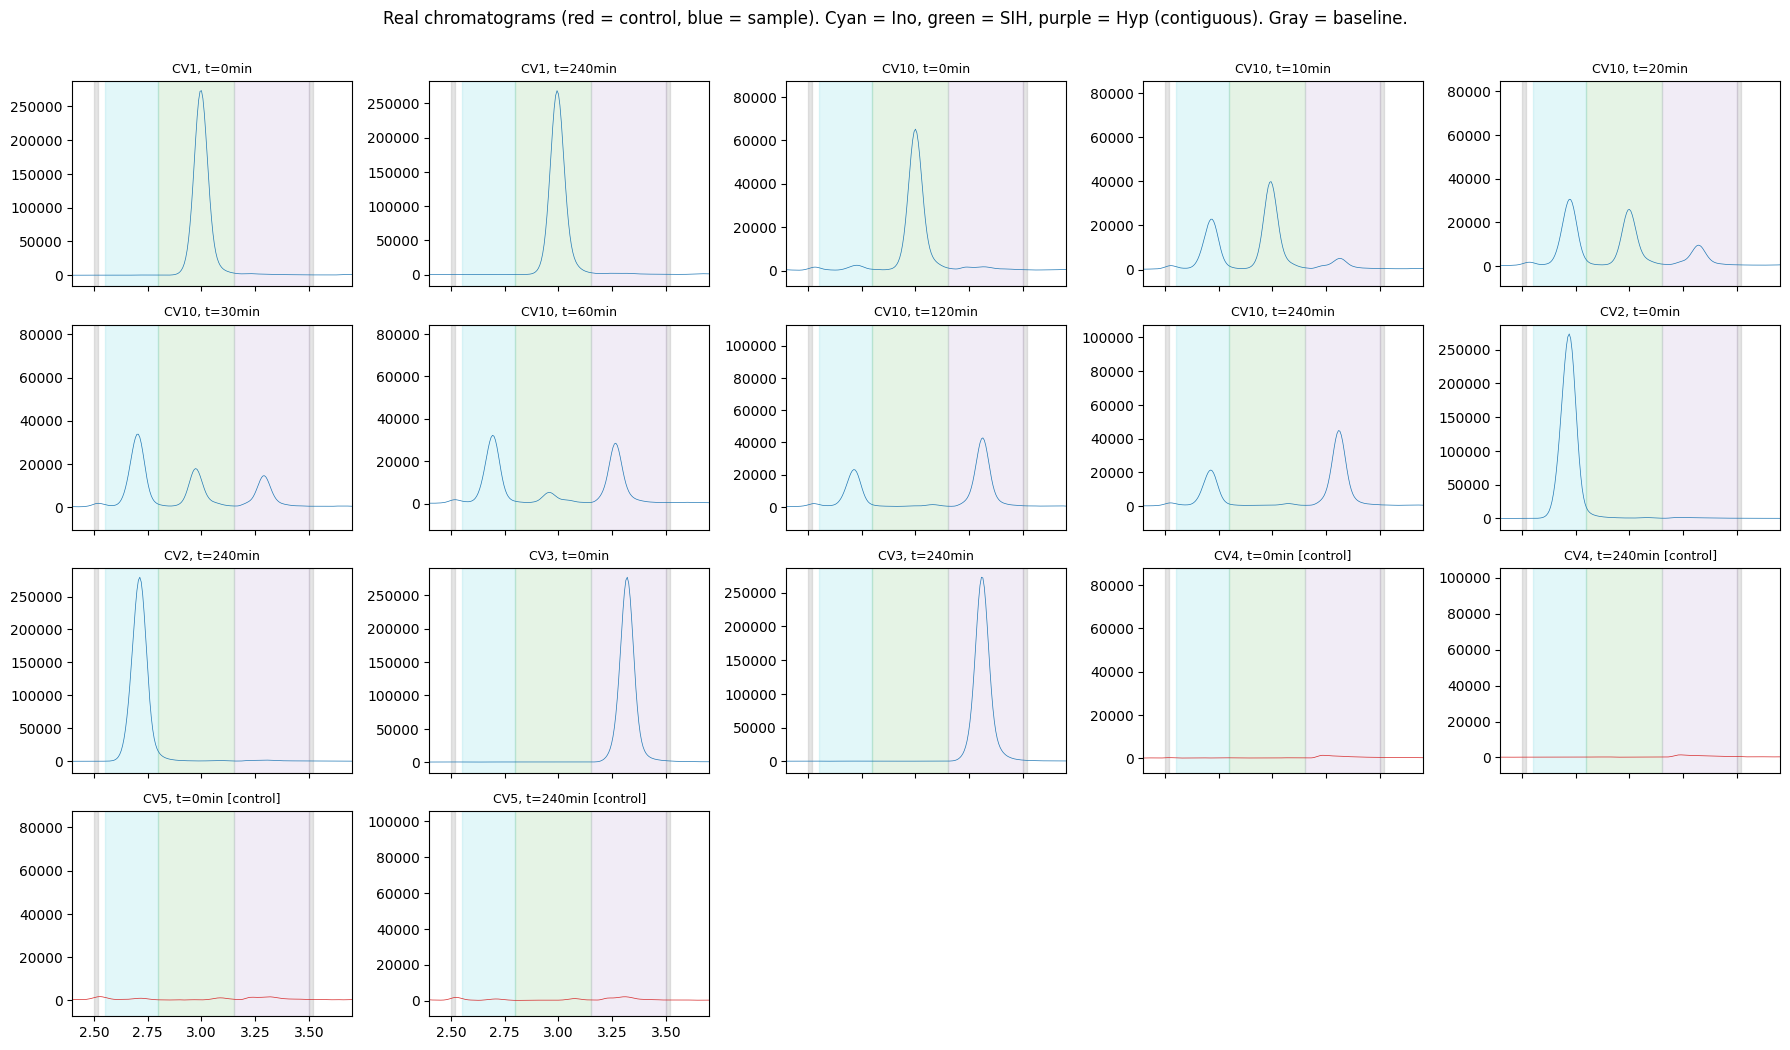

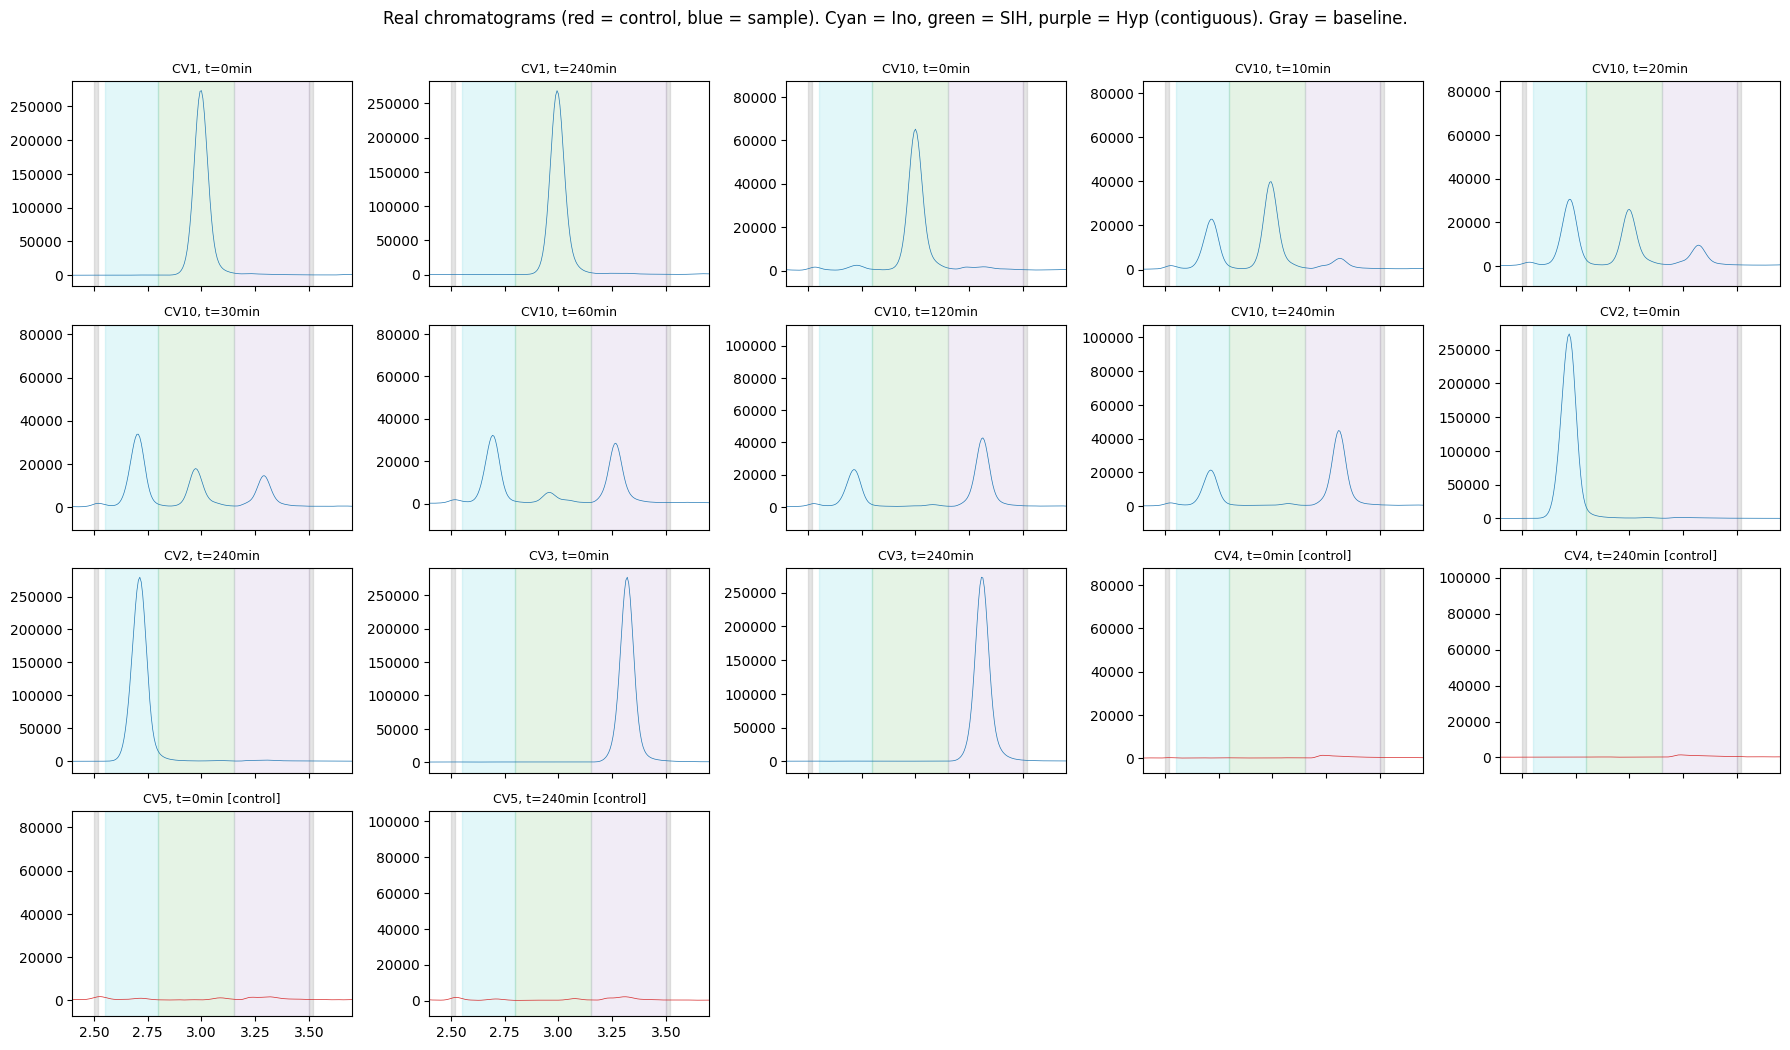

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Three analyte peak windows, contiguous (no gaps between them).
PEAK_WINDOWS = {
    "Ino": (2.55, 2.80, "tab:cyan"),
    "SIH": (2.80, 3.15, "tab:green"),
    "Hyp": (3.15, 3.50, "tab:purple"),
}

# Flatten samples -> chromatograms with metadata for plotting.
trace_meta = []
for sample in handler.samples:
    for chrom in sample.chromatograms:
        trace_meta.append({
            "sample_id": sample.id,
            "chrom_id": chrom.id,
            "is_control": sample.is_control,
            "time": np.asarray(chrom.time, dtype=np.float64),
            "signal": np.asarray(chrom.signal, dtype=np.float64),
            "reaction_time": chrom.reaction_time,
        })

n = len(trace_meta)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 2.6 * nrows), sharex=True)
ax_flat = axes.flatten() if nrows > 1 else axes
for i, meta in enumerate(trace_meta):
    ax = ax_flat[i]
    color = "C3" if meta["is_control"] else "C0"
    ax.plot(meta["time"], meta["signal"], color=color, lw=0.5)
    rt = meta["reaction_time"]
    rt_str = f", t={rt:.0f}min" if rt is not None else ""
    label = f"{meta['sample_id']}{rt_str}"
    if meta["is_control"]:
        label += " [control]"
    ax.set_title(label, fontsize=9)
    # Highlight the three contiguous analyte windows + the baseline regions.
    for low, high, band_color in PEAK_WINDOWS.values():
        ax.axvspan(low, high, color=band_color, alpha=0.12)
    ax.axvspan(2.50, 2.52, color="gray", alpha=0.20)
    ax.axvspan(3.50, 3.52, color="gray", alpha=0.20)
    ax.set_xlim(2.4, 3.7)

for ax in ax_flat[n:]:
    ax.axis("off")

fig.suptitle(
    "Real chromatograms (red = control, blue = sample). "
    "Cyan = Ino, green = SIH, purple = Hyp (contiguous). Gray = baseline.",
    y=1.005,
)
fig.tight_layout()
fig

In [13]:
from chromhandler.annotations import BaselineAnnotation, PeakAnnotation

# Annotate the three analytes as single-mode peaks. Used here only to drive
# baseline OLS + noise estimation on the full handler. The per-peak fitting
# in Section 9b uses its own (per-analyte) subset PreparedDatasets.
peak_anns = [
    PeakAnnotation(molecule_id="Ino", rt_min=2.55, rt_max=2.80, mode="single"),
    PeakAnnotation(molecule_id="SIH", rt_min=2.80, rt_max=3.15, mode="single"),
    PeakAnnotation(molecule_id="Hyp", rt_min=3.15, rt_max=3.50, mode="single"),
]
base_anns = [
    BaselineAnnotation(rt_min=2.50, rt_max=2.52),
    BaselineAnnotation(rt_min=3.55, rt_max=3.58),
]

real_dataset = handler.prepare_dataset(peak_anns, base_anns)
print(f"n_trace          = {real_dataset.n_trace}")
print(f"is_control mask  = {real_dataset.is_control}")
print(f"n controls       = {int(real_dataset.is_control.sum())}")
print(f"dt_global        = {real_dataset.dt_global:.5f} min")
print()
print("trace_ids (first 6):")
for tid in real_dataset.trace_ids[:6]:
    print(f"  {tid}")
print(f"  ... ({real_dataset.n_trace - 6} more)")

n_trace          = 17
is_control mask  = [False False False False False False False False False False False False
 False  True  True  True  True]
n controls       = 4
dt_global        = 0.00667 min

trace_ids (first 6):
  CV1/CV1_0min
  CV1/CV1_240min
  CV10/CV10_0min
  CV10/CV10_10min
  CV10/CV10_20min
  CV10/CV10_30min
  ... (11 more)


### 9b. Per-peak single-mode analysis

Each analyte lives in a different sample subset:

| Peak | Window (min) | Samples with this analyte |
|---|---|---|
| Ino | 2.55–2.80 | CV2 |
| SIH | 2.80–3.15 | CV10 (kinetic series), CV1 |
| Hyp | 3.15–3.50 | CV3 |

For each one we build a fresh `PreparedDataset` restricted to the relevant samples, run `build_priors` in `single` mode, and overlay the per-trace recovered prior loc on all 17 chromatograms.

In [14]:
from copy import deepcopy

# Per-peak setup: windows are contiguous so nothing falls between them.
PEAK_FITS = [
    {"mol": "Ino", "rt_min": 2.55, "rt_max": 2.80, "samples": ("CV2",)},
    {"mol": "SIH", "rt_min": 2.80, "rt_max": 3.15, "samples": ("CV10", "CV1")},
    {"mol": "Hyp", "rt_min": 3.15, "rt_max": 3.50, "samples": ("CV3",)},
]

priors_per_peak: dict[str, object] = {}
datasets_per_peak: dict[str, object] = {}

for cfg in PEAK_FITS:
    mol = cfg["mol"]
    # Build a handler subset containing only the samples that have this analyte.
    h_sub = Handler()
    h_sub.molecules = deepcopy(handler.molecules)
    h_sub.samples = [deepcopy(s) for s in handler.samples if s.id in cfg["samples"]]
    if not h_sub.samples:
        print(f"{mol:>3}: no samples available, skipping")
        continue

    p_ann = [PeakAnnotation(molecule_id=mol, rt_min=cfg["rt_min"], rt_max=cfg["rt_max"], mode="single")]
    b_ann = [
        BaselineAnnotation(rt_min=2.50, rt_max=2.52),
        BaselineAnnotation(rt_min=3.55, rt_max=3.58),
    ]
    try:
        ds_sub = h_sub.prepare_dataset(p_ann, b_ann)
        pr = build_priors(ds_sub, config=PriorConfig())
        priors_per_peak[mol] = pr[0]
        datasets_per_peak[mol] = ds_sub
        print(f"{mol:>3}: build_priors OK ({ds_sub.n_trace} traces, "
              f"mu_loc={pr[0].mu_left_loc:.4f} min, sigma_loc={float(np.exp(pr[0].log_sigma_left_loc)):.4f} min)")
    except (ValueError, NotImplementedError) as e:
        print(f"{mol:>3}: failed - {type(e).__name__}: {str(e)[:120]}")

Ino: build_priors OK (2 traces, mu_loc=2.7169 min, sigma_loc=0.0332 min)
SIH: build_priors OK (9 traces, mu_loc=3.0084 min, sigma_loc=0.0275 min)
Hyp: build_priors OK (2 traces, mu_loc=3.3136 min, sigma_loc=0.0310 min)


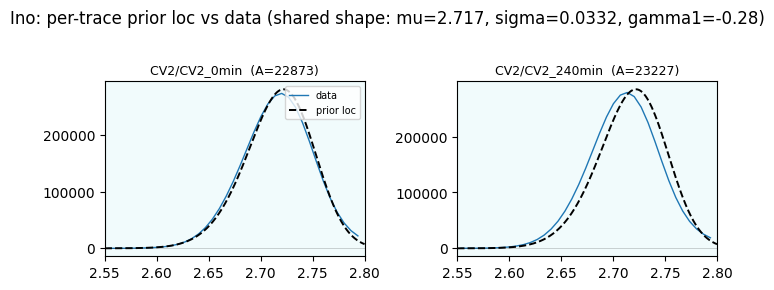

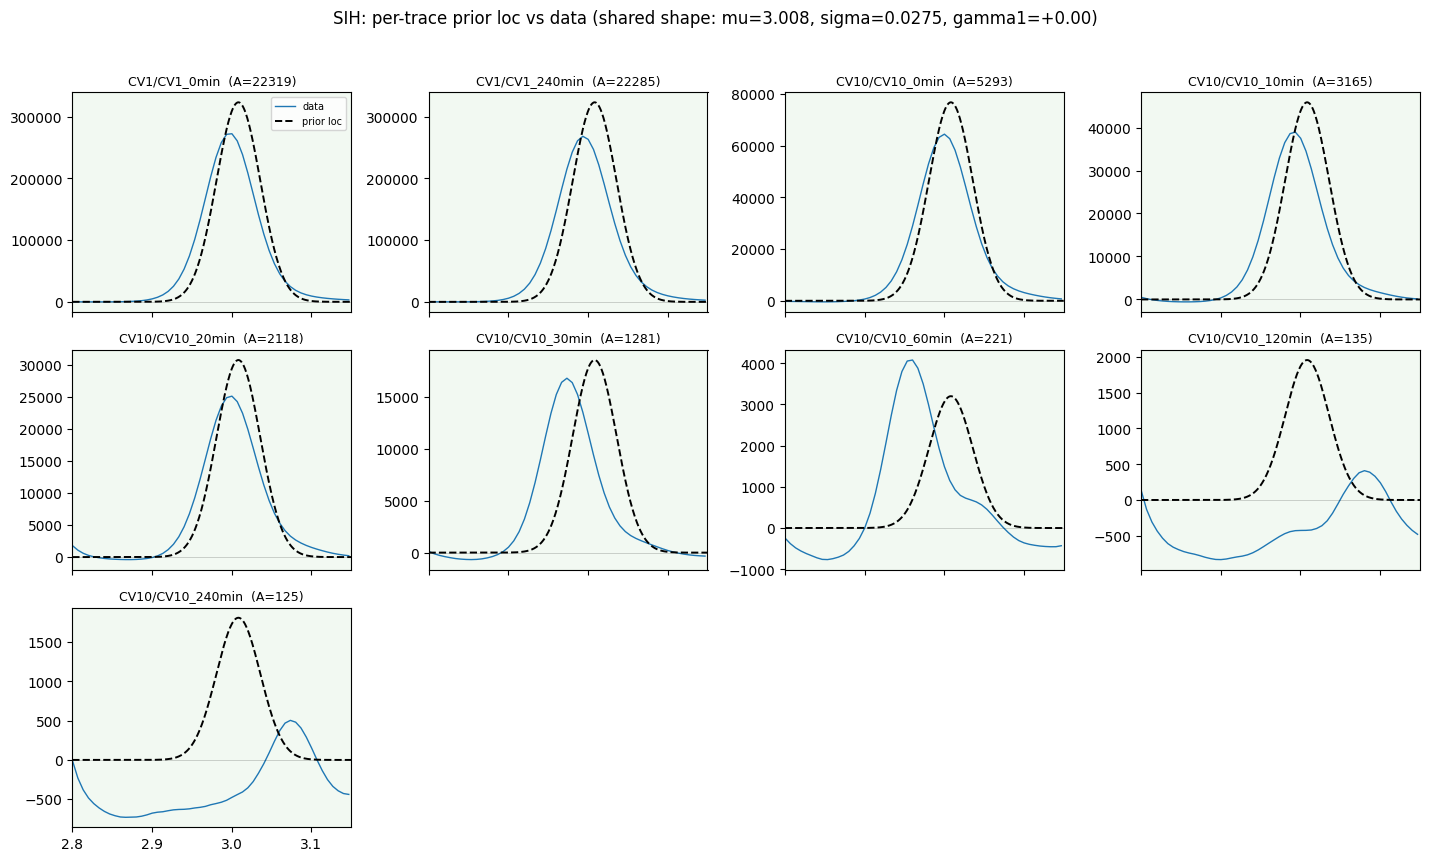

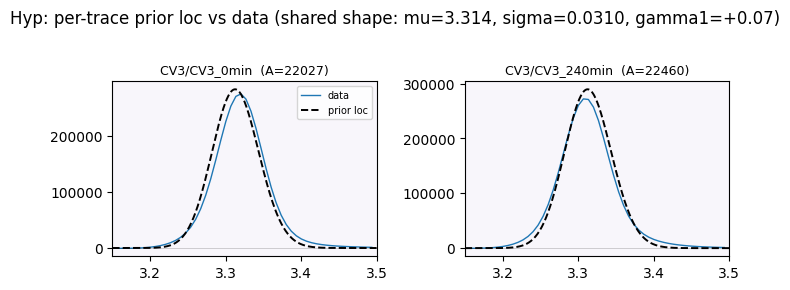

In [15]:
from IPython.display import display

from chromhandler.fitting.priors import SkewNormalPriors
from chromhandler.fitting.skew_normal import density_cp


def plot_per_peak_grid(mol: str):
    """One subplot per non-control trace in the peak's subset.

    Each subplot shows that specific trace's baseline-subtracted data
    inside the peak window, with the recovered prior loc overlaid (shape
    parameters are shared across traces; amplitude is per-trace).
    """
    cfg = next(c for c in PEAK_FITS if c["mol"] == mol)
    if mol not in priors_per_peak:
        return None
    p: SkewNormalPriors = priors_per_peak[mol]  # type: ignore[assignment]
    ds_sub = datasets_per_peak[mol]
    rt_min, rt_max = cfg["rt_min"], cfg["rt_max"]
    band_color = PEAK_WINDOWS[mol][2]

    non_control = [i for i in range(ds_sub.n_trace) if not ds_sub.is_control[i]]
    n = len(non_control)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.6 * ncols, 2.8 * nrows),
        squeeze=False, sharex=True,
    )
    ax_flat = axes.flatten()

    sigma_loc = float(np.exp(p.log_sigma_left_loc))
    t_dense = np.linspace(rt_min, rt_max, 500)
    sn_unit = np.asarray(density_cp(
        t_dense, p.mu_left_loc, sigma_loc, p.gamma1_left_loc,
    ))

    for i, sub_idx in enumerate(non_control):
        ax = ax_flat[i]
        t = ds_sub.time[sub_idx]
        s = ds_sub.signal[sub_idx]
        bs = s - (
            ds_sub.baseline_intercept[sub_idx]
            + ds_sub.baseline_slope[sub_idx] * t
        )
        mask = (t >= rt_min) & (t <= rt_max) & np.isfinite(bs)
        ax.plot(t[mask], bs[mask], color="C0", lw=1.0, label="data")

        A = float(np.exp(p.log_A_left_loc_per_trace[sub_idx]))
        ax.plot(t_dense, A * sn_unit, "k--", lw=1.4, label="prior loc")

        ax.axvspan(rt_min, rt_max, color=band_color, alpha=0.06)
        ax.set_xlim(rt_min, rt_max)
        ax.set_title(f"{ds_sub.trace_ids[sub_idx]}  (A={A:.0f})", fontsize=9)
        ax.axhline(0, color="k", lw=0.4, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7, loc="upper right")

    for ax in ax_flat[n:]:
        ax.axis("off")

    fig.suptitle(
        f"{mol}: per-trace prior loc vs data "
        f"(shared shape: mu={p.mu_left_loc:.3f}, sigma={sigma_loc:.4f}, "
        f"gamma1={p.gamma1_left_loc:+.2f})",
        y=1.02,
    )
    fig.tight_layout()
    return fig


for mol_name in ("Ino", "SIH", "Hyp"):
    f = plot_per_peak_grid(mol_name)
    if f is not None:
        display(f)
        plt.close(f)

### 9c. Diagnostic — controls only, per window

Sanity check: plot just the 4 control traces (CV4 × 2 timepoints + CV5 × 2 timepoints) in each of the three analyte windows, y-axis auto-scaled tightly to control data. If the controls are essentially flat baseline noise → no artefact peak in blanks → single mode is the right model for all three analytes (which is what Section 9b uses).

/var/folders/91/q7pk41915q9_tmkt4tw_yprh0000gn/T/ipykernel_14263/1098196657.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


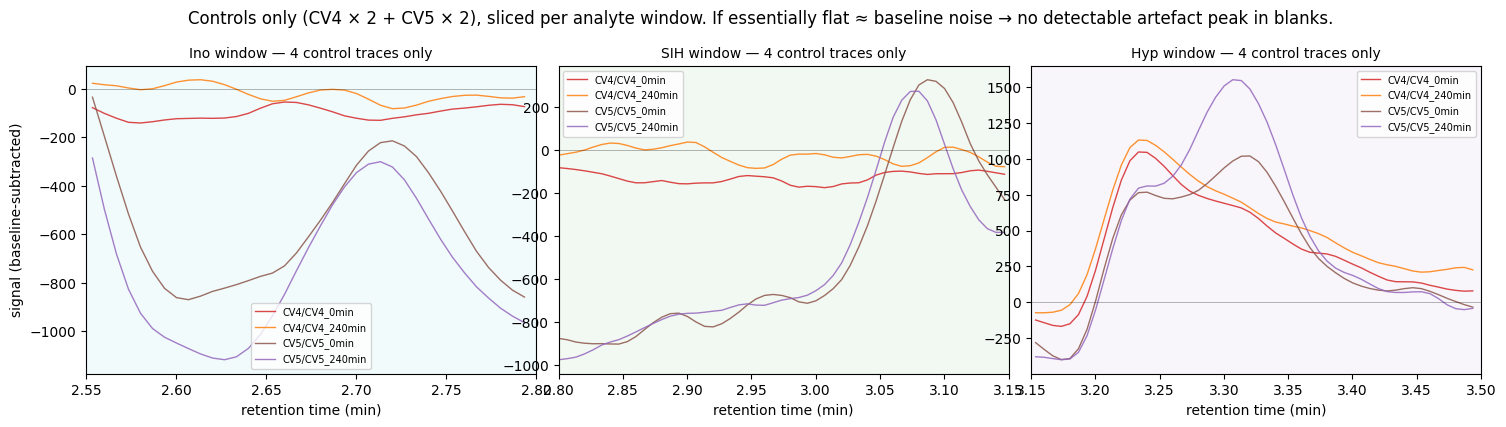

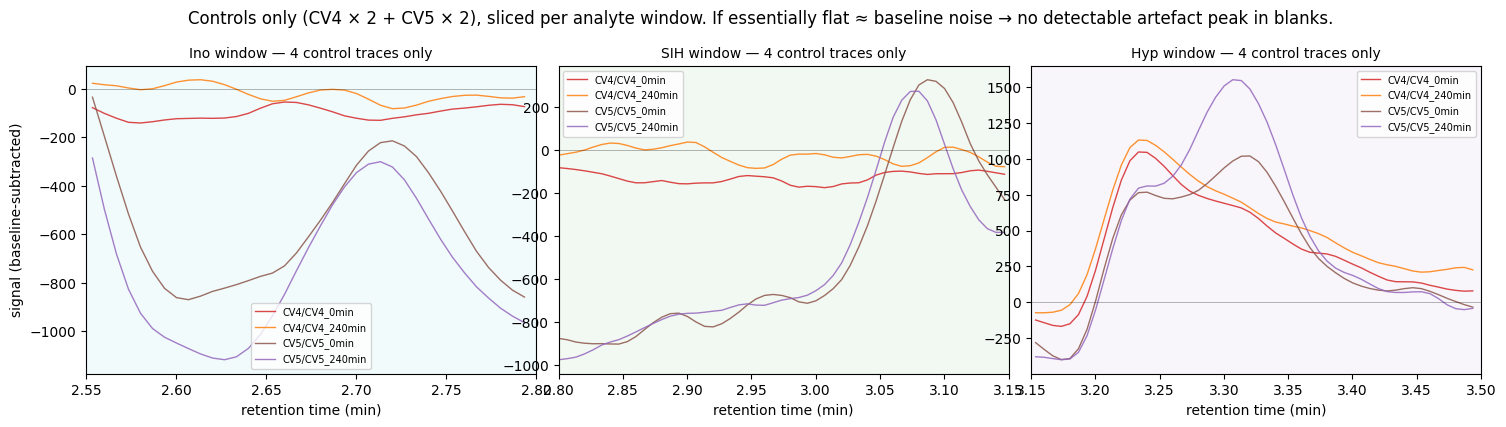

In [16]:
fig, axes = plt.subplots(
    1, 3, figsize=(18, 4),
    gridspec_kw={"wspace": 0.05},
    sharey=False,
)

control_indices = np.where(real_dataset.is_control)[0]
control_palette = ["C3", "C1", "C5", "C4"]  # 4 distinguishable warm colors

for ax, cfg in zip(axes, PEAK_FITS, strict=True):
    mol = cfg["mol"]
    rt_min, rt_max = cfg["rt_min"], cfg["rt_max"]
    band_color = PEAK_WINDOWS[mol][2]

    for color, trace_idx in zip(control_palette, control_indices, strict=False):
        t = real_dataset.time[trace_idx]
        s = real_dataset.signal[trace_idx]
        bs = s - (
            real_dataset.baseline_intercept[trace_idx]
            + real_dataset.baseline_slope[trace_idx] * t
        )
        mask = (t >= rt_min) & (t <= rt_max) & np.isfinite(bs)
        tid = real_dataset.trace_ids[trace_idx]
        ax.plot(t[mask], bs[mask], color=color, lw=1.0, alpha=0.85, label=tid)

    ax.axhline(0, color="k", lw=0.5, alpha=0.4)
    ax.axvspan(rt_min, rt_max, color=band_color, alpha=0.06)
    ax.set_xlim(rt_min, rt_max)
    ax.set_xlabel("retention time (min)")
    ax.set_title(f"{mol} window — 4 control traces only", fontsize=10)
    ax.legend(fontsize=7, loc="best")

axes[0].set_ylabel("signal (baseline-subtracted)")
fig.suptitle(
    "Controls only (CV4 × 2 + CV5 × 2), sliced per analyte window. "
    "If essentially flat ≈ baseline noise → no detectable artefact peak in blanks.",
    y=1.02,
)
fig.tight_layout()
fig

### 9d. End-to-end MCMC fit on SIH — `fit()`

Now the full pipeline: the same `PreparedDataset` we used for `build_priors` in section 9b goes into `fit()`, which internally calls `build_priors` → `run_mcmc` → `FitResult`. We subset to **CV10 (the kinetic series) + CV1 (no enzyme) + CV4/CV5 (controls)** for the SIH analyte and run a small MCMC (200 warmup + 200 samples × 2 chains, ~1–2 minutes).

The `FitResult` object exposes:

- `result.idata` — raw `arviz.InferenceData` for downstream ArviZ tooling
- `result.summary()` — mean / sd / HDI / R-hat / ESS DataFrame
- `result.diagnostics()` — quick `{r_hat_max, ess_min_bulk, n_divergent, fit_healthy}` dict
- `result.plot_traces()` — per-parameter convergence diagnostic
- `result.plot_prior_overlay()` — `priors_demo`-style prior loc on data (no MCMC needed)
- `result.plot_prior_predictive()` — 95% HDI band of model-from-priors on data
- `result.plot_fit()` — 95% HDI band of posterior predictive on data

In [17]:
from copy import deepcopy

from chromhandler.fitting import ModelConfig, fit

# Subset the handler to samples relevant for SIH (the kinetic substrate)
# plus controls. This matches the integration test in
# tests/integration/test_fitter_asm.py.
h_sih = Handler()
h_sih.molecules = deepcopy(handler.molecules)
h_sih.samples = [
    deepcopy(s) for s in handler.samples
    if s.id in {"CV10", "CV1", "CV4", "CV5"}
]

# Single-mode annotation on the contiguous SIH window.
sih_peak_anns = [
    PeakAnnotation(molecule_id="SIH", rt_min=2.80, rt_max=3.15, mode="single"),
]
sih_base_anns = [
    BaselineAnnotation(rt_min=2.50, rt_max=2.52),
    BaselineAnnotation(rt_min=3.55, rt_max=3.58),
]
sih_dataset = h_sih.prepare_dataset(sih_peak_anns, sih_base_anns)

result = fit(
    sih_dataset,
    model_config=ModelConfig(num_warmup=200, num_samples=200, num_chains=2, seed=0),
)

print("=== diagnostics ===")
for k, v in result.diagnostics().items():
    print(f"  {k:<22} {v}")
print()
print("=== summary (first 6 rows) ===")
print(result.summary().head(6))

/Users/max/code/Chromhandler/chromhandler/fitting/model.py:343: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(


  0%|          | 0/400 [00:00<?, ?it/s]

warmup:   0%|          | 1/400 [00:00<03:50,  1.73it/s, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   6%|▌         | 24/400 [00:00<00:12, 29.08it/s, 1023 steps of size 1.11e-12. acc. prob=0.47]

warmup:   7%|▋         | 28/400 [00:02<00:32, 11.37it/s, 1023 steps of size 7.16e-13. acc. prob=0.51]

...

sample: 100%|█████████▉| 399/400 [02:04<00:00,  2.49it/s, 1023 steps of size 8.81e-11. acc. prob=0.95]

sample: 100%|██████████| 400/400 [02:04<00:00,  2.52it/s, 1023 steps of size 8.81e-11. acc. prob=0.95]

sample: 100%|██████████| 400/400 [02:04<00:00,  3.21it/s, 1023 steps of size 8.81e-11. acc. prob=0.95]

=== diagnostics ===
  r_hat_max              9863944627761746.0
  r_hat_max_param        baseline_intercept[0]
  ess_min_bulk           2.0
  ess_min_param          baseline_intercept[0]
  n_divergent            0
  n_samples_total        400
  fit_healthy            False

=== summary (first 6 rows) ===
                           mean      sd    hdi_3%   hdi_97%  mcse_mean  \
baseline_intercept[0]  -329.350   3.666  -333.012  -325.689      2.540   
baseline_intercept[1]  -397.023   2.182  -399.201  -394.842      1.512   
baseline_intercept[2]  3000.604  42.330  2958.332  3042.887     29.327   
baseline_intercept[3]  3819.863  29.119  3790.788  3848.954     20.174   
baseline_intercept[4]  3026.190  54.875  2971.383  3080.995     38.018   
baseline_intercept[5]  4167.479  63.973  4103.593  4231.378     44.322   

                       mcse_sd  ess_bulk  ess_tail         r_hat  
baseline_intercept[0]    0.000       2.0       2.0  9.863945e+15  
baseline_intercept[1]      NaN       2.0 

/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:992: RuntimeWarning: invalid value encountered in sqrt
  mcse_sd_value = np.sqrt(varsd)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/max/code/Chromhandler/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:992: Runti

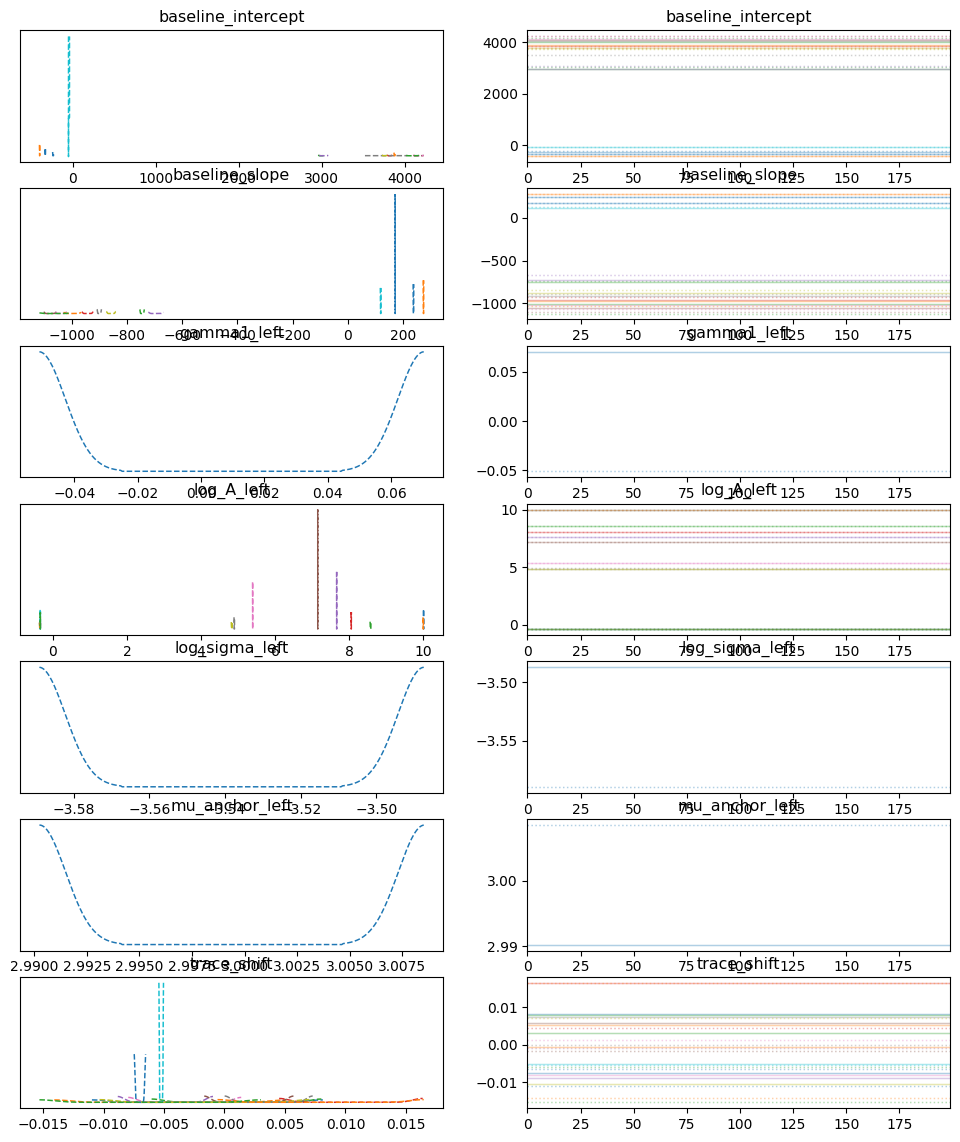

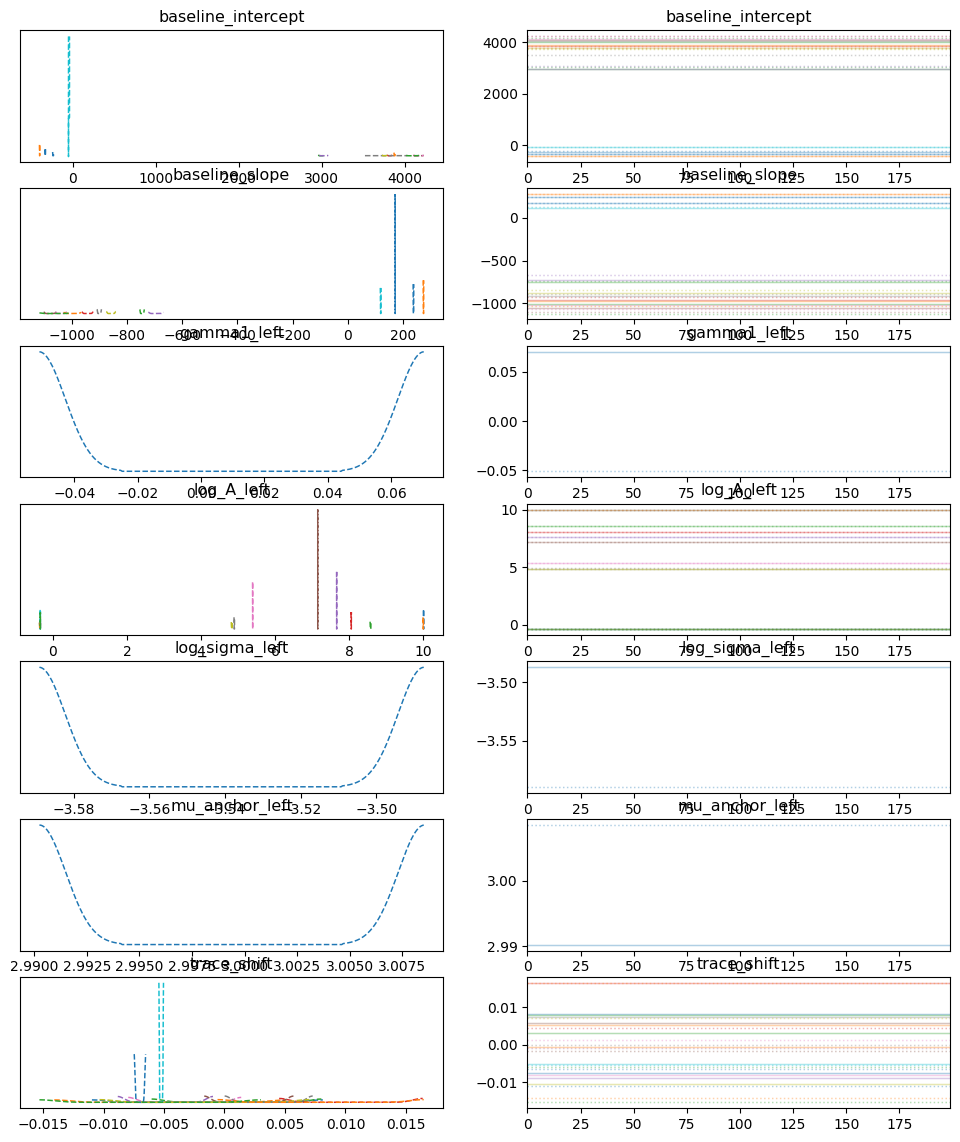

In [18]:
result.plot_traces()

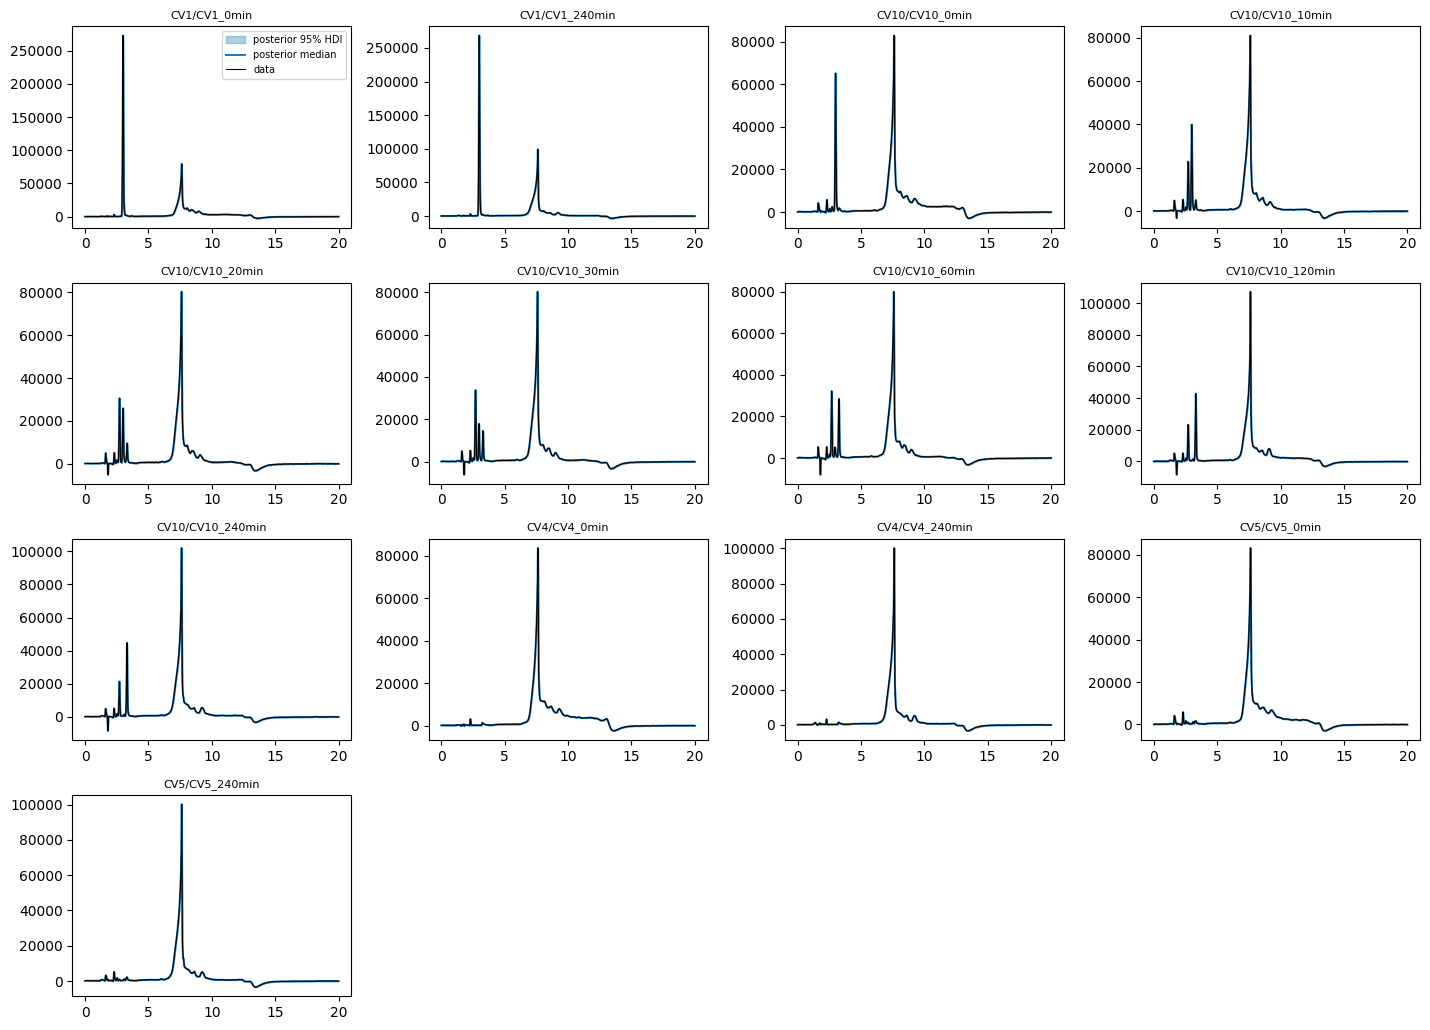

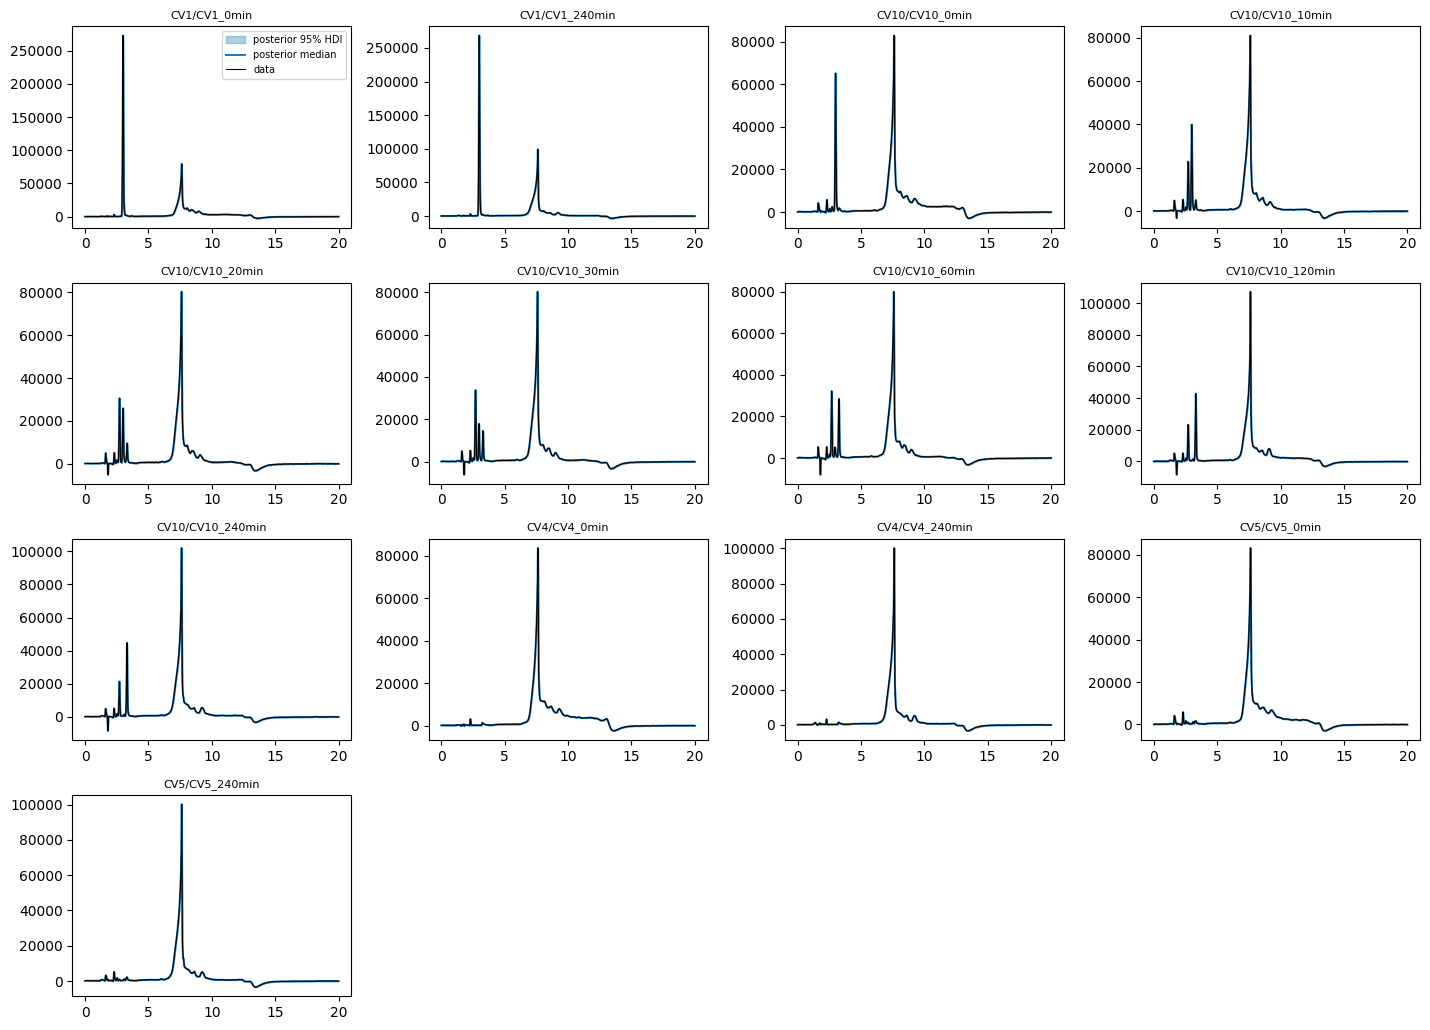

In [19]:
result.plot_fit()

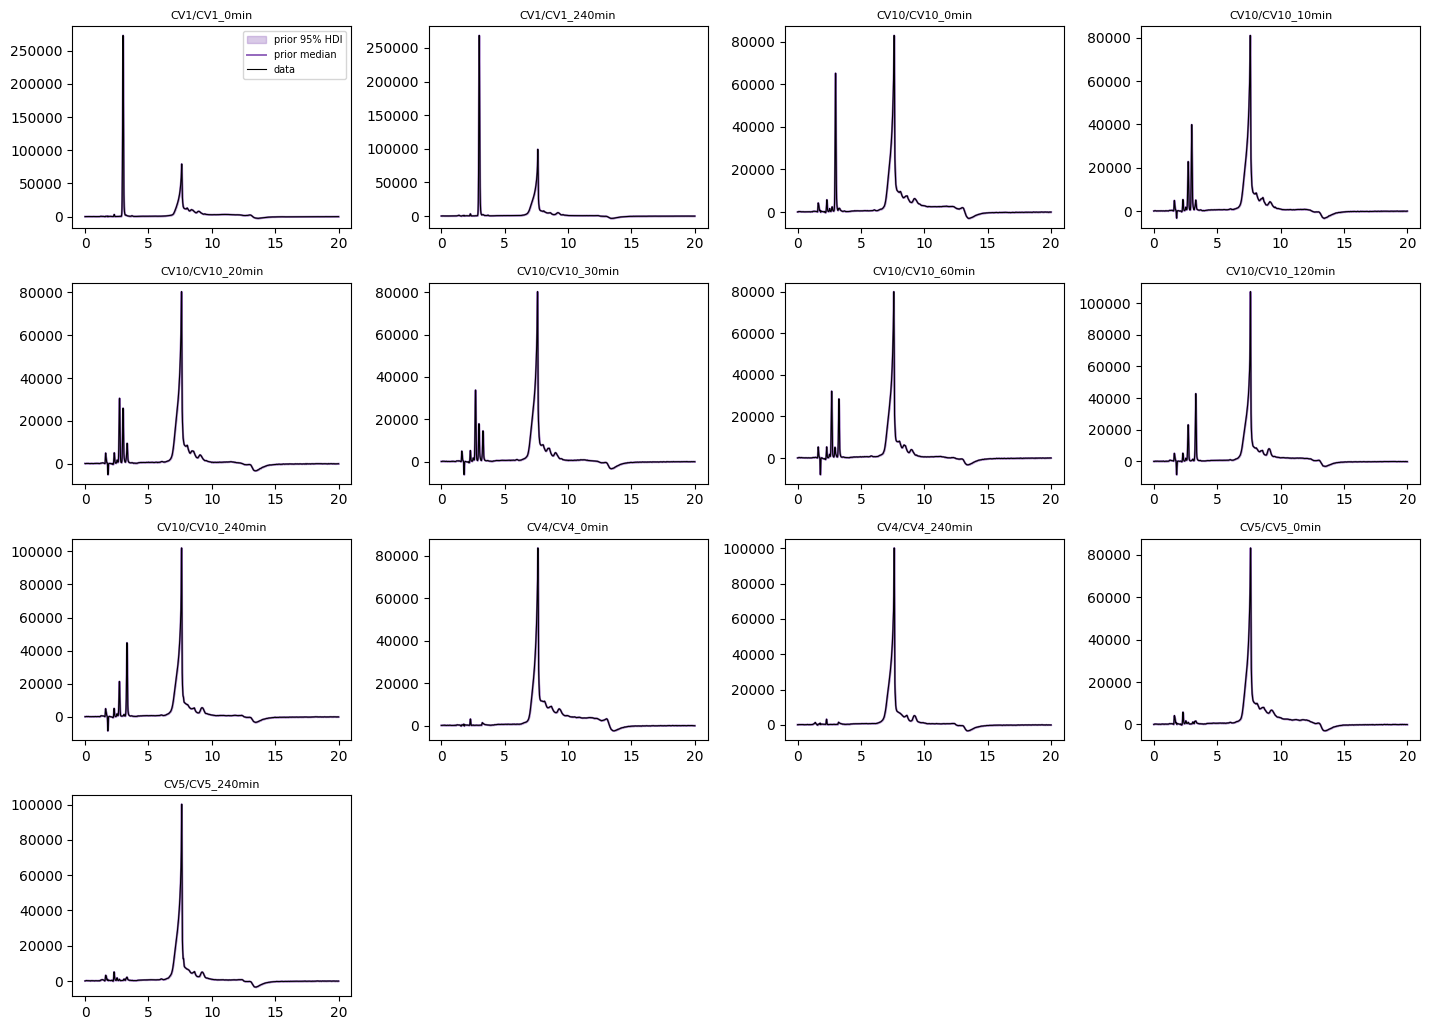

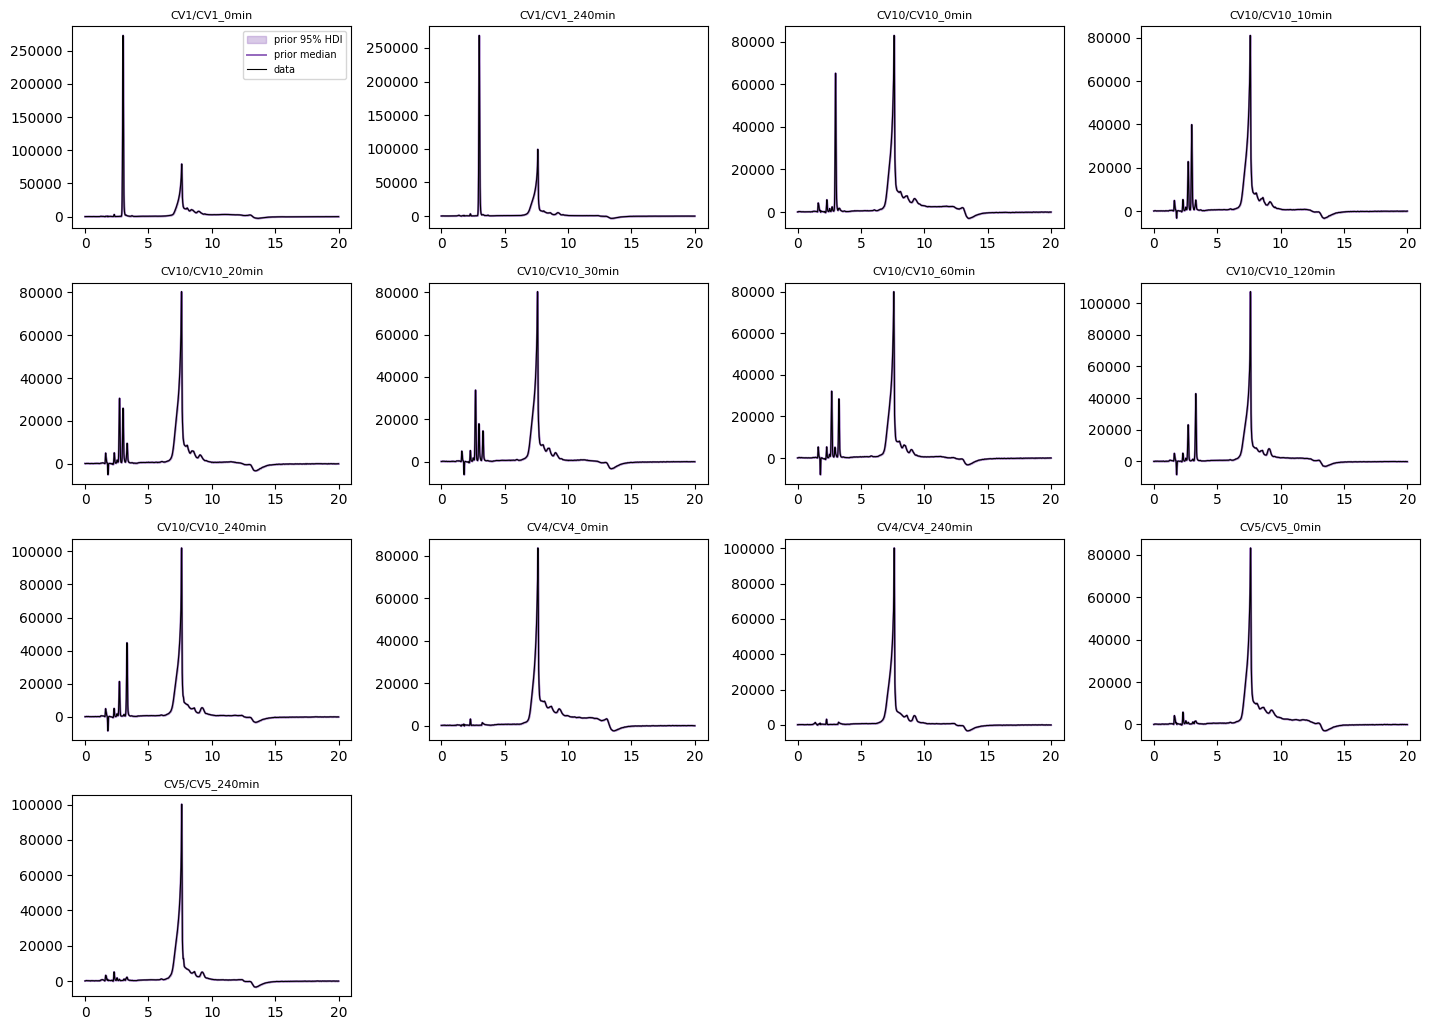

In [20]:
result.plot_prior_predictive()

## 10. What's next

The full fitter pipeline is now shipped: `from chromhandler.fitting import fit` runs the end-to-end **PreparedDataset → priors → MCMC → FitResult** flow. Single-mode peaks are fully supported; the `FitResult` object exposes ArviZ-native diagnostics plus four debug plots (`plot_traces`, `plot_prior_overlay`, `plot_prior_predictive`, `plot_fit`).

**Doublet support** is the next building block. The model is already structured for it — every sample-site uses the `_left` suffix, `SAMPLED_RIGHT_*` constants are defined (empty), `_validate_single_mode_only` lives in `run_mcmc` (one-line removal when ready), and `TODO(doublet)` markers in `model.py` and `fitter.py` flag every extension point. Adding doublet support is an additive change, not a refactor — roughly half the surface area of the single-mode work.

Other reasonable next steps:

1. **Heteroscedastic noise floor** in `model.py`. The current Normal likelihood with a per-trace fixed noise σ produces NaN R-hat on very high-SNR data (CV1 SIH peak at SNR ~55 000) because the posterior collapses below float64 precision. A small floor like `σ ← max(σ, 0.01 · A_peak)` would smooth this without changing the result for typical data.
2. **Parallel chains on multiple CPU/GPU devices.** Currently chains run sequentially because `numpyro.set_host_device_count(8)` (set at `chromhandler.fitting` import time) only takes effect if the process starts with `XLA_FLAGS="--xla_force_host_platform_device_count=8"`. Worth wiring up properly.
3. **More plot types.** ArviZ already covers pair plots, posterior densities, etc. via `result.idata`. Custom chromatography-specific views (per-trace residual maps, kinetic-decay area summaries) could land in `posterior.py` + `fitter.py` if needed.